### import <3

#### where we for the data:
where we got the data?
https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html
The data consist of 3k PBMCs from a Healthy Donor and are freely available from 10x Genomics (here from this webpage). 

In [1]:
import numpy as np
import pandas as pd
import scipy.io
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

### loading data

In [3]:
DATA_DIR = Path(".")

X = scipy.io.mmread(DATA_DIR / "matrix.mtx").tocsr()   # genes x cells
genes = pd.read_csv(DATA_DIR / "genes.tsv", sep="\t", header=None)
barcodes = pd.read_csv(DATA_DIR / "barcodes.tsv", sep="\t", header=None)

gene_names = genes.iloc[:, 1].astype(str).values if genes.shape[1] > 1 else genes.iloc[:, 0].astype(str).values
cell_names = barcodes.iloc[:, 0].astype(str).values

# convert to cells x genes
X = X.T.tocsr()

print("cells x genes:", X.shape)

cells x genes: (2700, 32738)


### filtering

In [4]:
cell_n_genes = np.asarray((X > 0).sum(axis=1)).ravel()
gene_n_cells = np.asarray((X > 0).sum(axis=0)).ravel()

keep_cells = cell_n_genes >= 200
keep_genes = gene_n_cells >= 3

X = X[keep_cells][:, keep_genes]
cell_names = cell_names[keep_cells]
gene_names = gene_names[keep_genes]

print("after filtering:", X.shape)


after filtering: (2700, 13714)


### normalization 

In [5]:
target_sum = 1e4

cell_sums = np.asarray(X.sum(axis=1)).ravel()
cell_sums[cell_sums == 0] = 1

scale = target_sum / cell_sums
X_norm = sp.diags(scale) @ X

X_log = X_norm.copy()
X_log.data = np.log1p(X_log.data)

### HVG

In [6]:
X_dense = X_log.toarray()

gene_means = X_dense.mean(axis=0)
gene_vars = X_dense.var(axis=0, ddof=1)

# dispersion
dispersion = gene_vars / (gene_means + 1e-8)

n_hvg = min(2000, X_dense.shape[1])
hvg_idx = np.argsort(dispersion)[-n_hvg:]

X_hvg = X_dense[:, hvg_idx]
hvg_gene_names = gene_names[hvg_idx]

print("HVG matrix:", X_hvg.shape)

HVG matrix: (2700, 2000)


### PCA

In [11]:
#scaling
X_scaled = X_hvg - X_hvg.mean(axis=0)
gene_std = X_hvg.std(axis=0, ddof=1)
gene_std[gene_std == 0] = 1.0
X_scaled = X_scaled / gene_std

In [ ]:
# covariance
n_samples = X_scaled.shape[0]
cov_matrix = (X_scaled.T @ X_scaled) / (n_samples - 1)

# eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# choose number of PC
n_pcs = min(50, eigvecs.shape[1])

# top principal directions
principal_components = eigvecs[:, :n_pcs]

# project cells onto PCs
PCAembedding = X_scaled @ principal_components

# explained variance ratio
explained_variance_ratio = eigvals / eigvals.sum()

print("PCA shape:", PCAembedding.shape)

PCA shape: (2700, 50)


In [ ]:
pca_df = pd.DataFrame(
    PCAembedding,
    index=cell_names,
    columns=[f"PC{i+1}" for i in range(PCAembedding.shape[1])]
)
pca_df.to_csv("PCAembedding.csv")

loadings_df = pd.DataFrame(
    principal_components,
    index=hvg_gene_names,
    columns=[f"PC{i+1}" for i in range(principal_components.shape[1])]
)
loadings_df.to_csv("PC_loadings.csv")

variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigvals))],
    "eigenvalue": eigvals,
    "explained_variance_ratio": explained_variance_ratio
})
variance_df.to_csv("PCA_variance.csv", index=False)

print("saving PCAembedding.csv, PC_loadings.csv, PCA_variance.csv")

Saved PCAembedding.csv, PC_loadings.csv, PCA_variance.csv


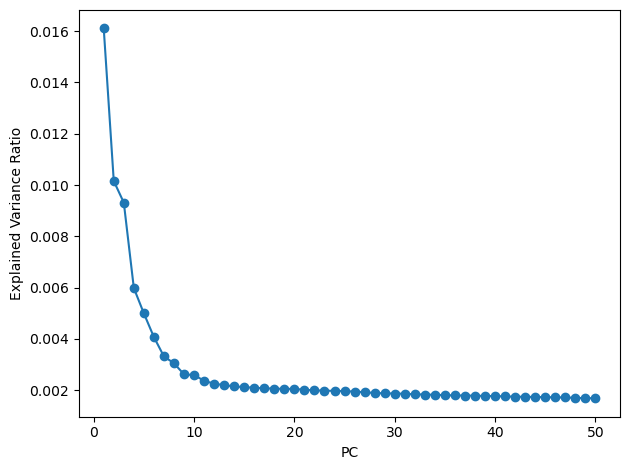

In [18]:
k = min(50, len(explained_variance_ratio))

plt.plot(range(1, k + 1),
         explained_variance_ratio[:k],
         marker='o')

plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")
plt.tight_layout()
plt.show()

### validation of PCA

In [23]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# use the exact same input matrix as your manual PCA
# this assumes your manual PCA was run on X_scaled
X_validate = X_scaled.copy()

# package PCA
n_pcs_check = PCAembedding.shape[1]
pca_pkg = PCA(n_components=n_pcs_check, svd_solver="full")
X_pkg = pca_pkg.fit_transform(X_validate)

# explained variance ratio from package
pkg_ratio = pca_pkg.explained_variance_ratio_

# manual explained variance ratio for the same number of PCs
manual_ratio = explained_variance_ratio[:n_pcs_check]

# correlations between manual PCs and package PCs
# sign can flip in PCA, so compare absolute correlation
pc_correlations = []
for i in range(n_pcs_check):
    corr = np.corrcoef(PCAembedding[:, i], X_pkg[:, i])[0, 1]
    pc_correlations.append(corr)

pc_correlations = np.array(pc_correlations)
abs_pc_correlations = np.abs(pc_correlations)

# compare pairwise distances in embedding space as another sanity check
manual_dist = np.linalg.norm(PCAembedding[:, :10], axis=1)
pkg_dist = np.linalg.norm(X_pkg[:, :10], axis=1)
dist_corr = np.corrcoef(manual_dist, pkg_dist)[0, 1]

# summary table
validation_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_pcs_check)],
    "manual_var_ratio": manual_ratio,
    "package_var_ratio": pkg_ratio,
    "abs_difference": np.abs(manual_ratio - pkg_ratio),
    "pc_correlation": pc_correlations,
    "abs_pc_correlation": abs_pc_correlations
})

print("Validation summary")
print(validation_df.head(5))


Validation summary
    PC  manual_var_ratio  package_var_ratio  abs_difference  pc_correlation  \
0  PC1          0.016100           0.016100    6.938894e-18             1.0   
1  PC2          0.010156           0.010156    0.000000e+00            -1.0   
2  PC3          0.009314           0.009314    3.469447e-18            -1.0   
3  PC4          0.005984           0.005984    8.673617e-18            -1.0   
4  PC5          0.004996           0.004996    3.469447e-18            -1.0   

   abs_pc_correlation  
0                 1.0  
1                 1.0  
2                 1.0  
3                 1.0  
4                 1.0  


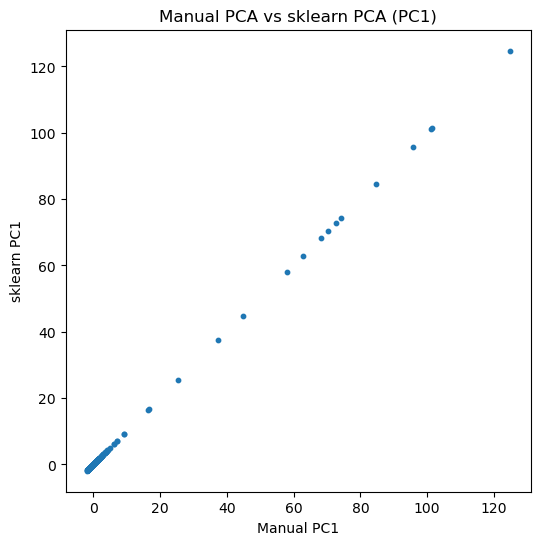

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(PCAembedding[:, 0], X_pkg[:, 0], s=10)
plt.xlabel("Manual PC1")
plt.ylabel("sklearn PC1")
plt.title("Manual PCA vs sklearn PCA (PC1)")
plt.show()